# Secondary Plots

Contains plots that build on data cached for plots from `provenance_explorer.analysis.*`.

In [3]:
from provenance_explorer.registry.registry_all import WORK
from provenance_explorer.plotting import apply_style

apply_style()

import json
import matplotlib.pyplot as plt
from collections import defaultdict

cache_path = WORK / "provenance-explorer-cache"

## CDM Type distribution bar chart

Requires `.correctness.data_model_types_plot` to be cached. 

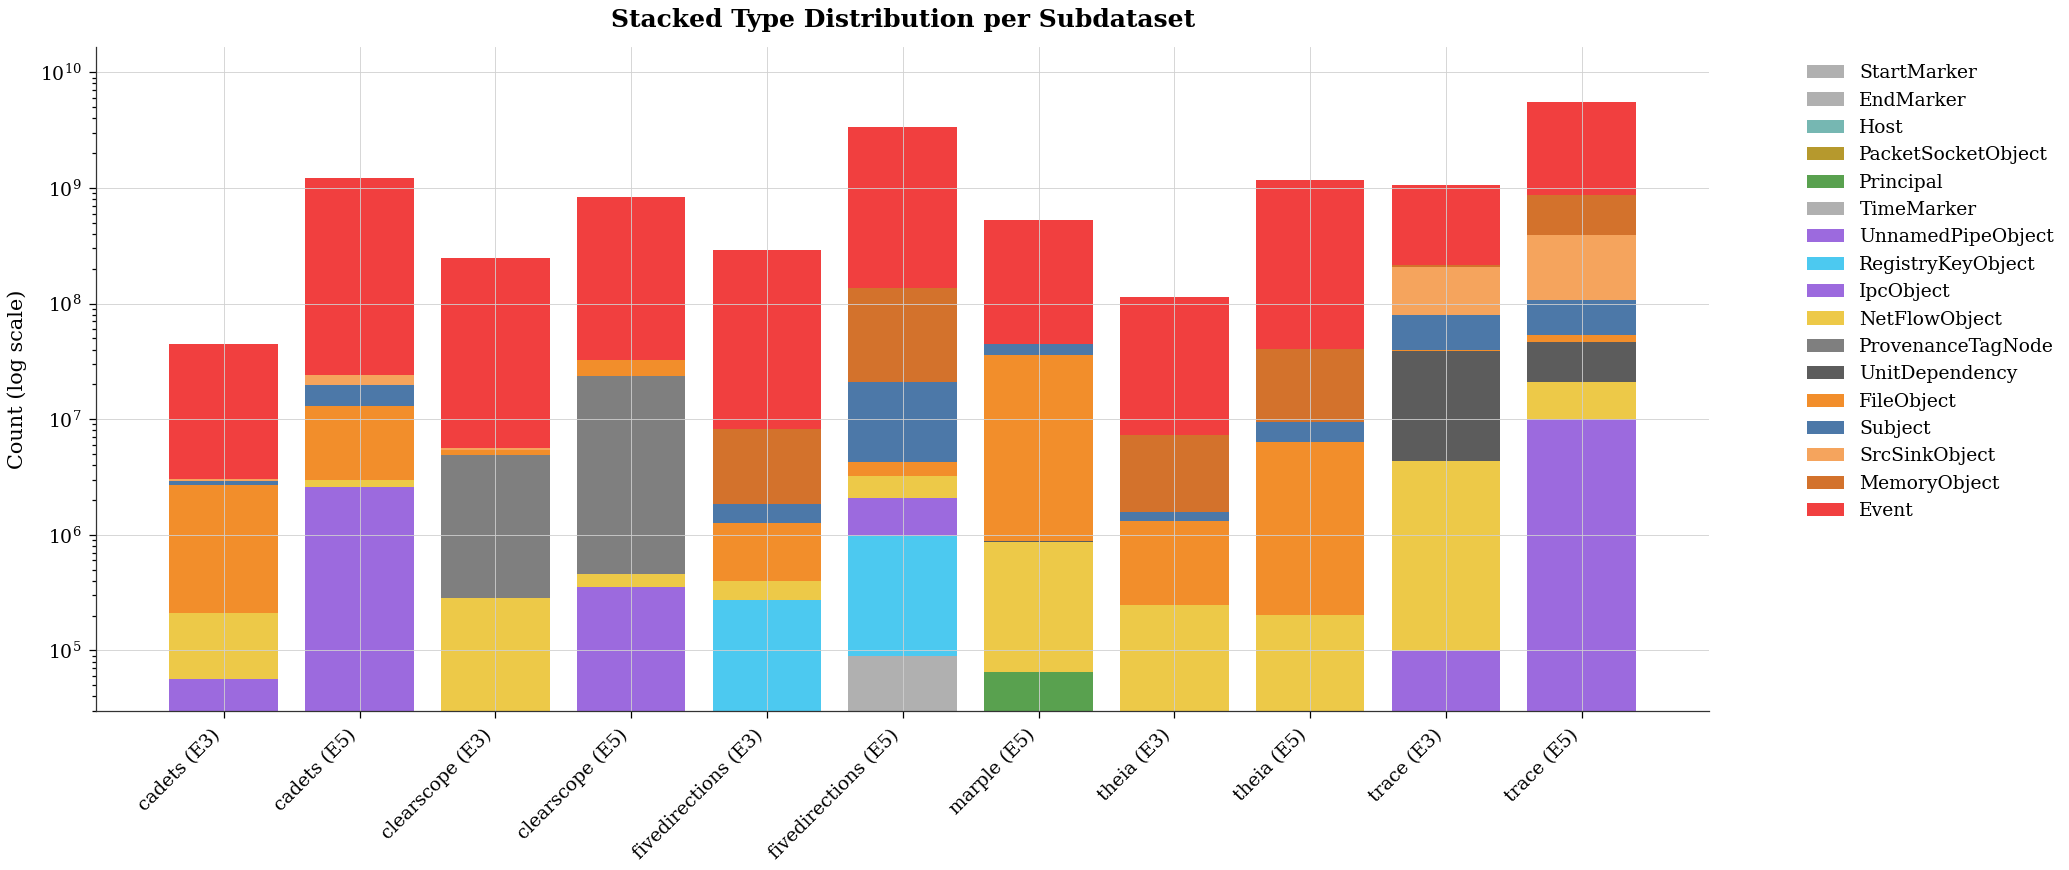

In [ ]:
data_models = ["cdm20.json", "cdm18.json"]

type_colors = {
    # process & friends
    "Subject": "#4C78A8",
    "IpcObject": "#9C6ADE",
    "UnnamedPipeObject": "#9C6ADE",
    
    # rare
    "Principal": "#59A14F",
    "Host": "#76B7B2",

    # the goat
    "Event": "#F13F3F",
    
    # project specific stuff and cdm metadata
    "TimeMarker": "#B0B0B0",
    "StartMarker": "#B0B0B0",
    "EndMarker": "#B0B0B0",
    "ProvenanceTagNode": "#7F7F7F",
    "UnitDependency": "#5C5C5C",

    # file-ish
    "FileObject": "#F28E2B",
    "SrcSinkObject": "#F5A45D",
    "MemoryObject": "#D3722C",

    # windows only
    "RegistryKeyObject": "#4CC9F0",

    # network-ish 
    "NetFlowObject": "#EDC948",
    "PacketSocketObject": "#B6992D",
}

bars = []
global_type_totals = defaultdict(int)

for data_model in data_models:
    summary_path = cache_path / "data_model_types_plot" / data_model
    with open(summary_path, "r") as fh:
        summary = json.load(fh)

    for subdataset, subdict in summary.items():
        type_counts = defaultdict(int)

        for key, val in subdict.items():
            c = sum(val.values())
            type_counts[key] += c
            global_type_totals[key] += c

        label = f"{subdataset} ({"E3" if data_model == "cdm18.json" else "E5"})"
        bars.append((label, dict(type_counts)))

bars = sorted(bars, key= lambda t: t[0])
types_sorted = sorted(global_type_totals, key=lambda t: global_type_totals[t])

fig, ax = plt.subplots(figsize=(14, 6))
x = list(range(len(bars)))
bottom = [0] * len(bars)

for t in types_sorted:
    values = [counts.get(t, 0) for _, counts in bars]
    ax.bar(x, values, bottom=bottom, label=t,color=type_colors.get(t, "#CCCCCC"),)
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([label for label, _ in bars], rotation=45, ha="right")

ax.set_ylabel("Count (log scale)")
ax.set_title("Stacked Type Distribution per Subdataset")

ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()